In [16]:
import numpy as np
import altair as alt
import pandas as pd
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
df: pd.DataFrame = pd.read_csv("student_performance/student_performance.csv")
# convert str to categorical
for col in df.columns:
    if df[col].dtype == "str":
        df[col] = df[col].astype("category")

In [18]:
df.describe()

,id,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,714.000000,710.000000,709.000000,708.000000,712.000000,710.000000,711.000000,710.000000,714.000000,709.000000,705.000000,711.000000,711.000000,710.000000,714.000000,714.000000,714.000000
mean,320.633053,16.743662,2.523272,2.324859,1.560393,1.918310,0.219409,3.919718,3.182073,3.187588,1.487943,2.285513,3.520394,3.669014,11.413165,11.560224,11.892157
std,187.042097,1.213085,1.131762,1.102448,0.751373,0.818735,0.585953,0.975312,1.059473,1.184916,0.912467,1.278776,1.452271,4.667388,2.731335,2.948818,3.255526
min,0.000000,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,159.250000,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,317.500000,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,482.750000,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,648.000000,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [19]:
print(f"Number of missing values:\n{df.isnull().sum()}")

Number of missing values:
id            0
school        0
sex           0
age           4
address       2
famsize       5
Pstatus       7
Medu          5
Fedu          6
Mjob          1
Fjob          3
reason        4
guardian      3
traveltime    2
studytime     4
failures      3
schoolsup     2
famsup        3
paid          4
activities    7
nursery       5
higher        3
internet      5
romantic      5
famrel        4
freetime      0
goout         5
Dalc          9
Walc          3
health        3
absences      4
G1            0
G2            0
G3            0
dtype: int64


<Axes: >

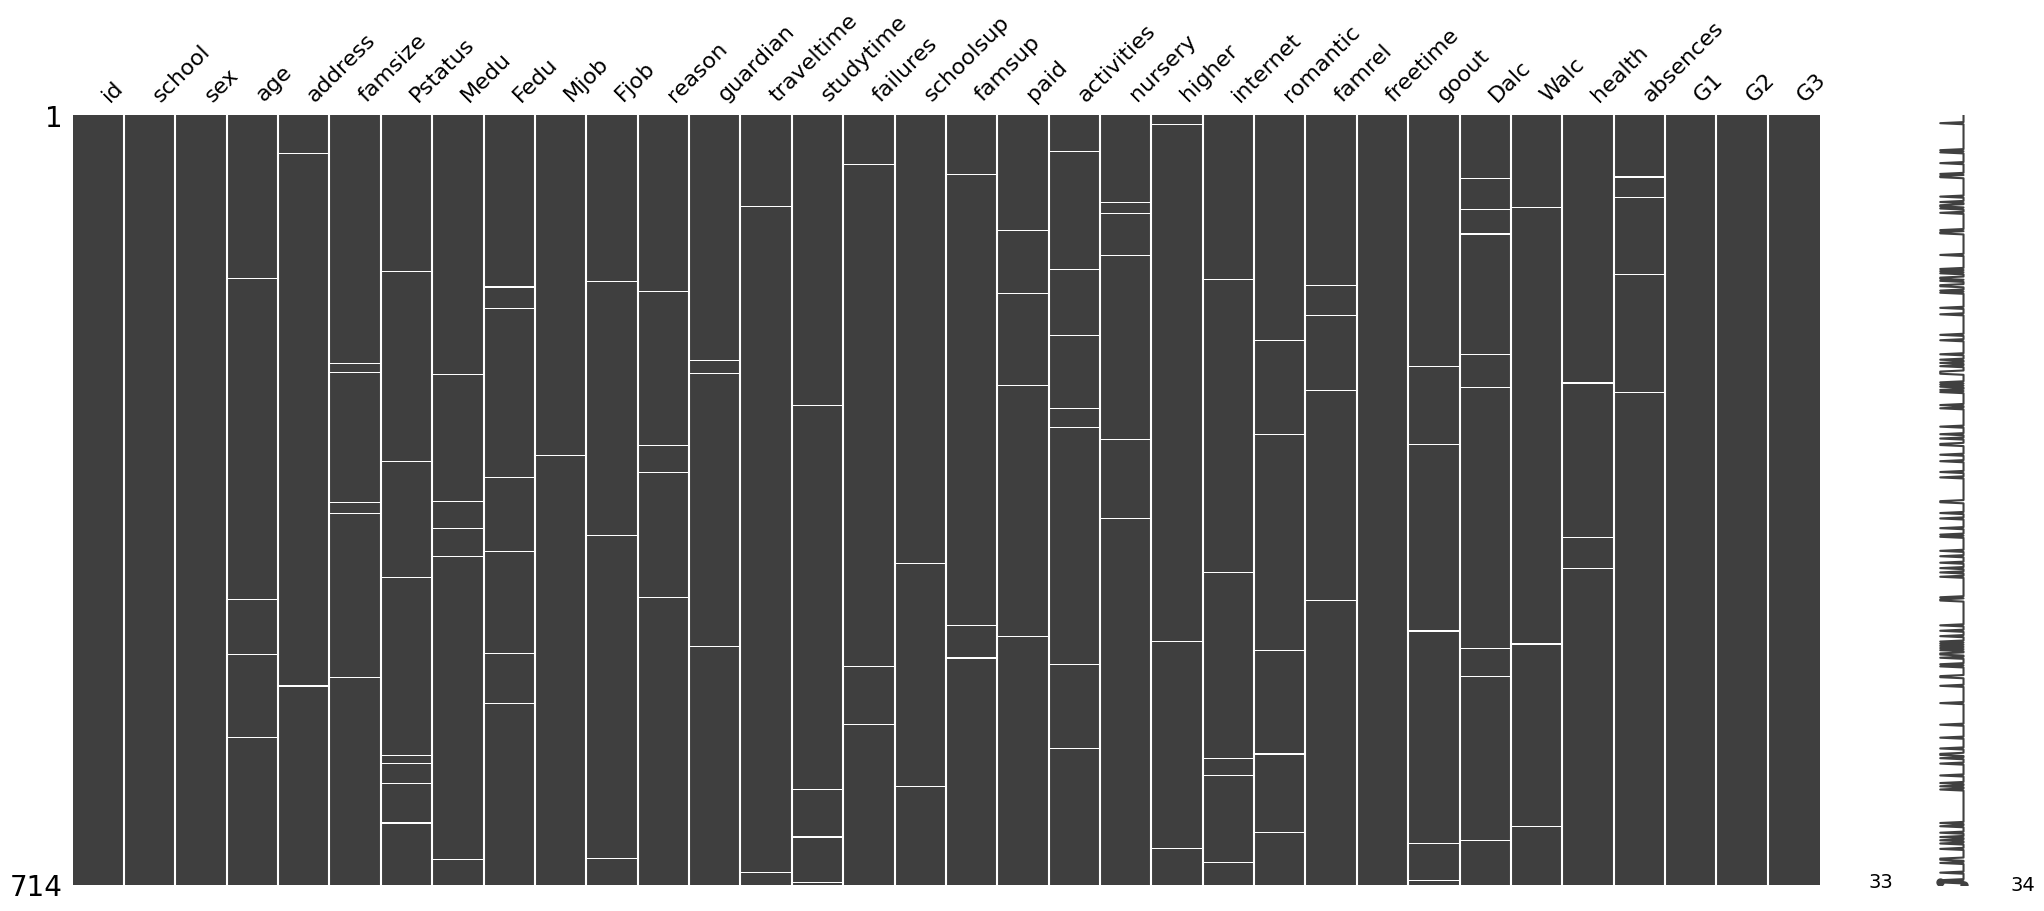

In [20]:
# Visualize missing data
msno.matrix(df)

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   id          714 non-null    int64   
 1   school      714 non-null    category
 2   sex         714 non-null    category
 3   age         710 non-null    float64 
 4   address     712 non-null    category
 5   famsize     709 non-null    category
 6   Pstatus     707 non-null    category
 7   Medu        709 non-null    float64 
 8   Fedu        708 non-null    float64 
 9   Mjob        713 non-null    category
 10  Fjob        711 non-null    category
 11  reason      710 non-null    category
 12  guardian    711 non-null    category
 13  traveltime  712 non-null    float64 
 14  studytime   710 non-null    float64 
 15  failures    711 non-null    float64 
 16  schoolsup   712 non-null    category
 17  famsup      711 non-null    category
 18  paid        710 non-null    category
 19  activities  707 non

In [22]:
# fill na 
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])


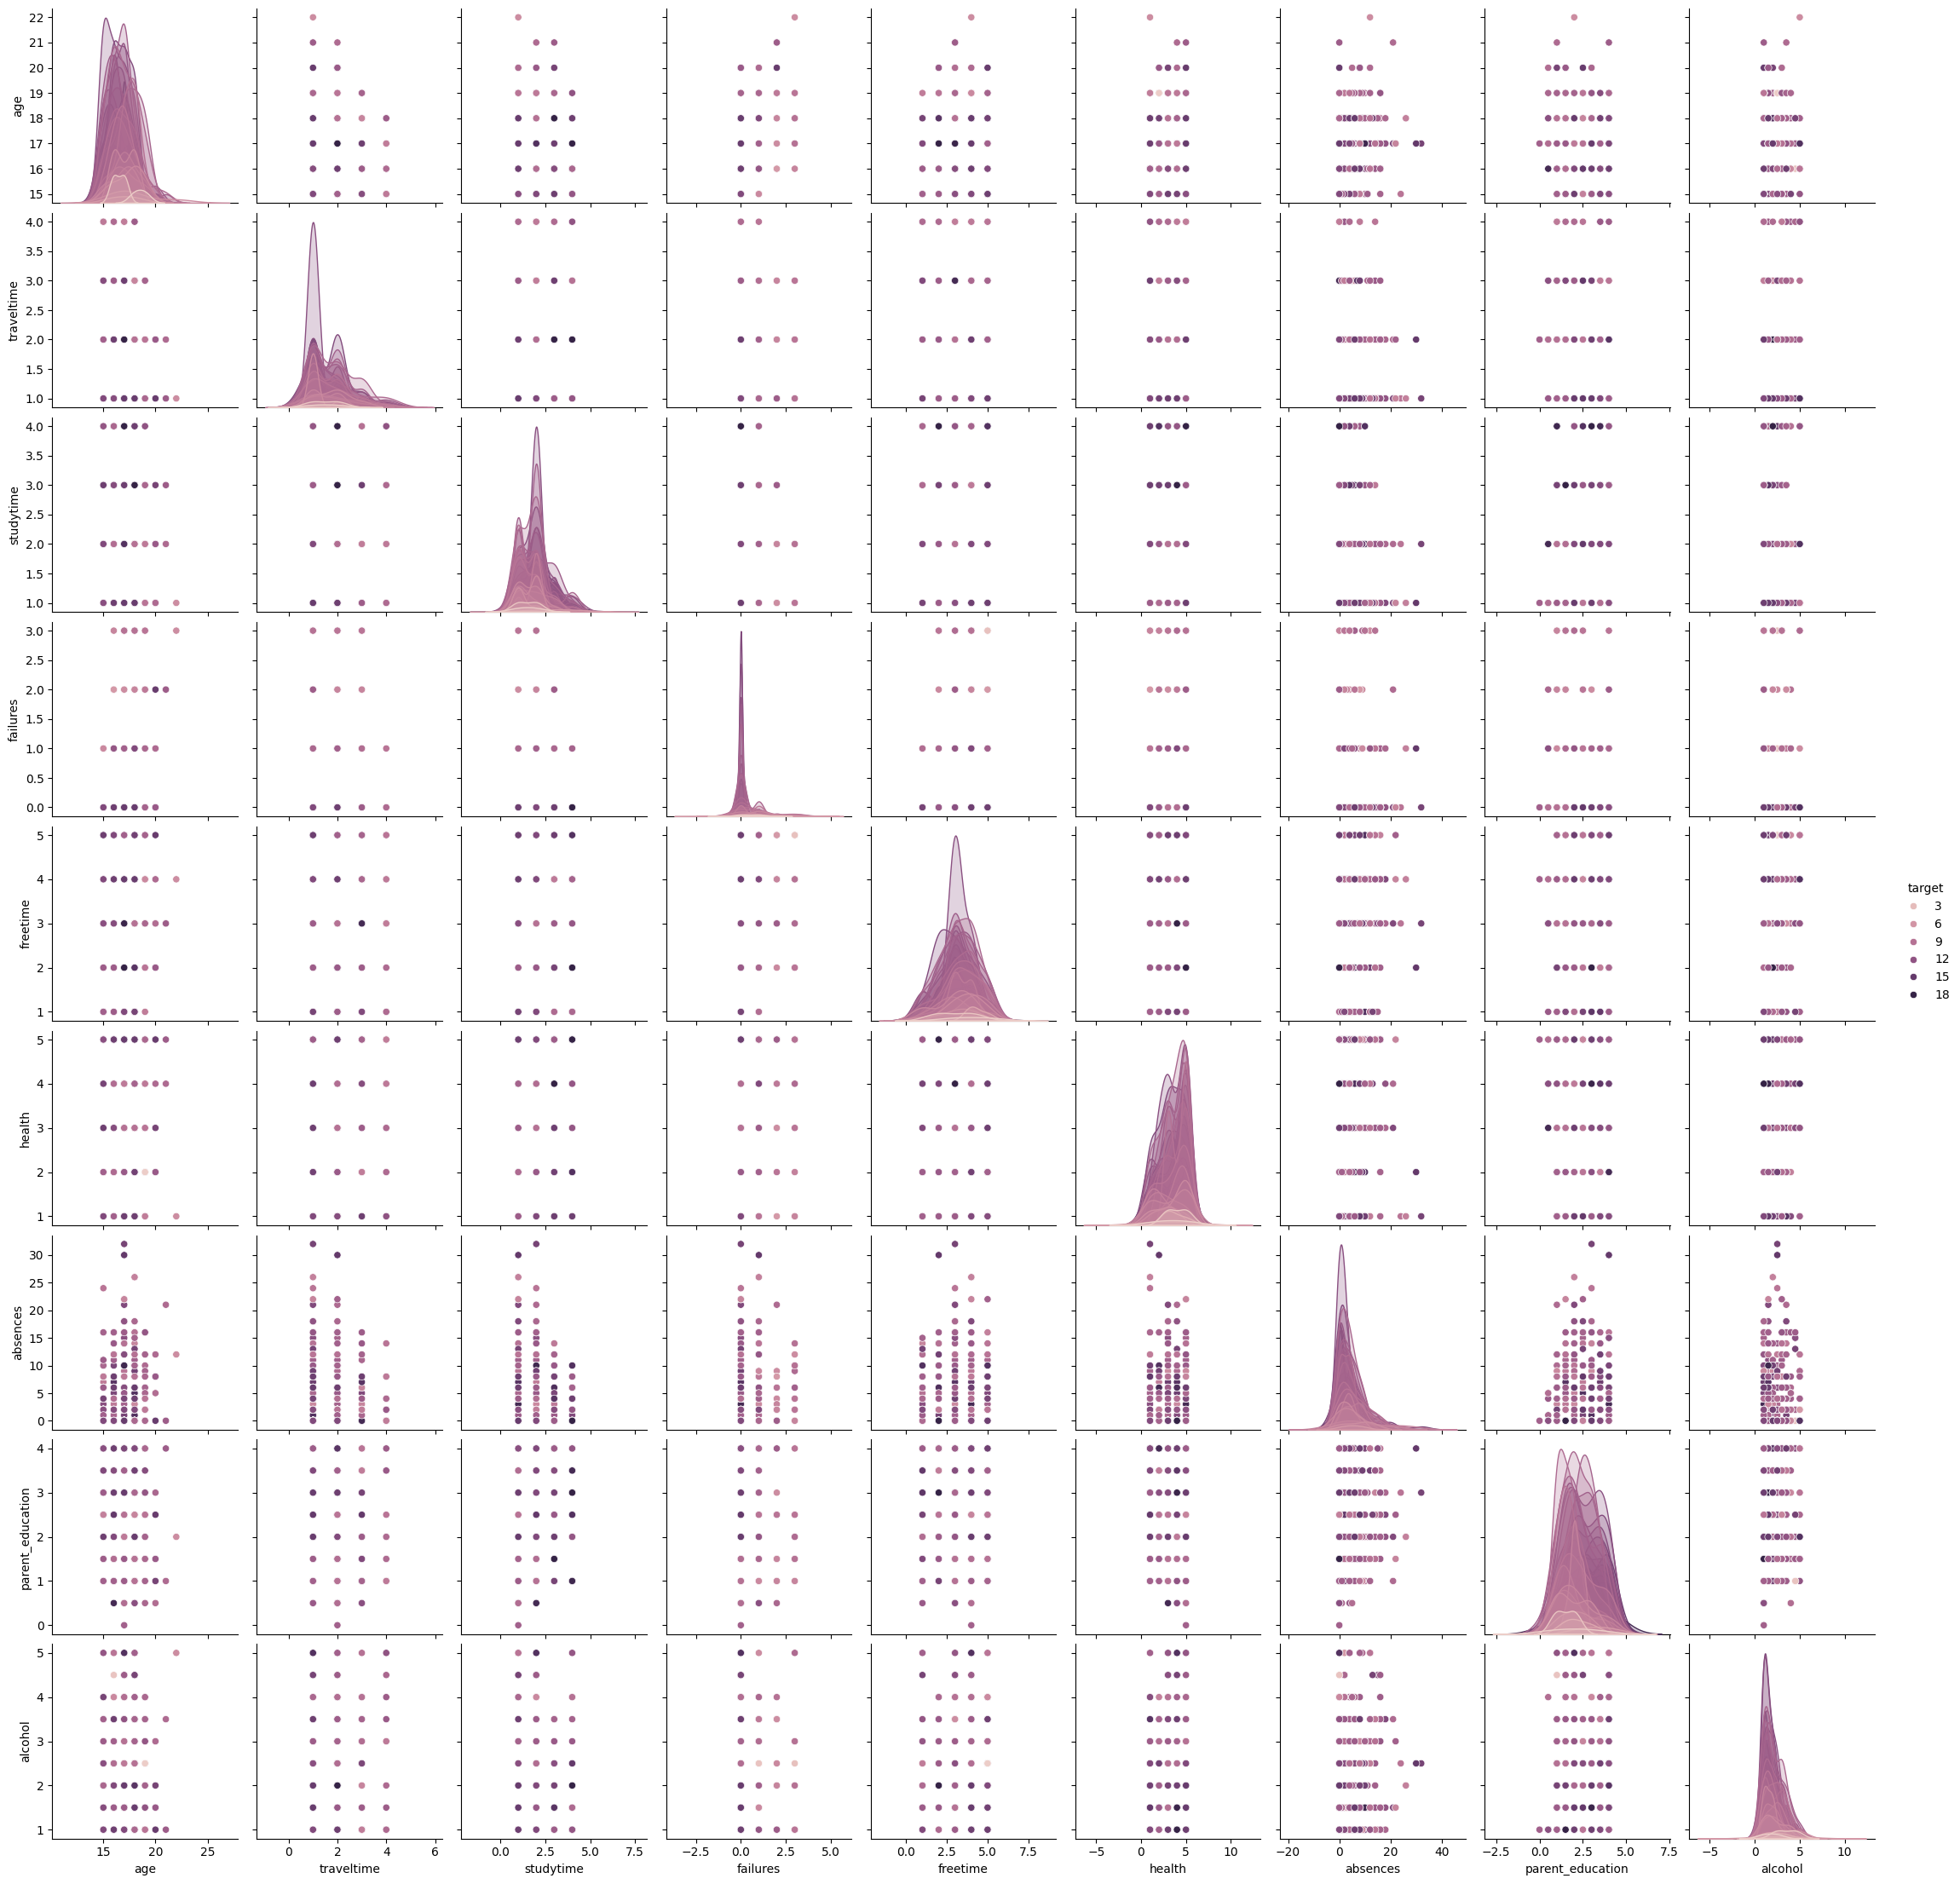

In [23]:
# Pairplot of all features colored by average target score (G1, G2, G3)
plot_df = df.copy()
# merge target variables and parent education into single columns for easier plotting
plot_df["target"] = plot_df[["G1", "G2", "G3"]].mean(axis=1)
plot_df["parent_education"] = plot_df[["Medu", "Fedu"]].mean(axis=1)
plot_df["alcohol"] = plot_df[["Dalc", "Walc"]].mean(axis=1)

plot_df = plot_df.drop(columns=["id","G1", "G2", "G3", "Medu", "Fedu", "Dalc", "Walc"])
# drop some columns for better visualization
plot_df = plot_df.drop(columns=["famrel", "goout"])

sns.pairplot(plot_df, hue="target")

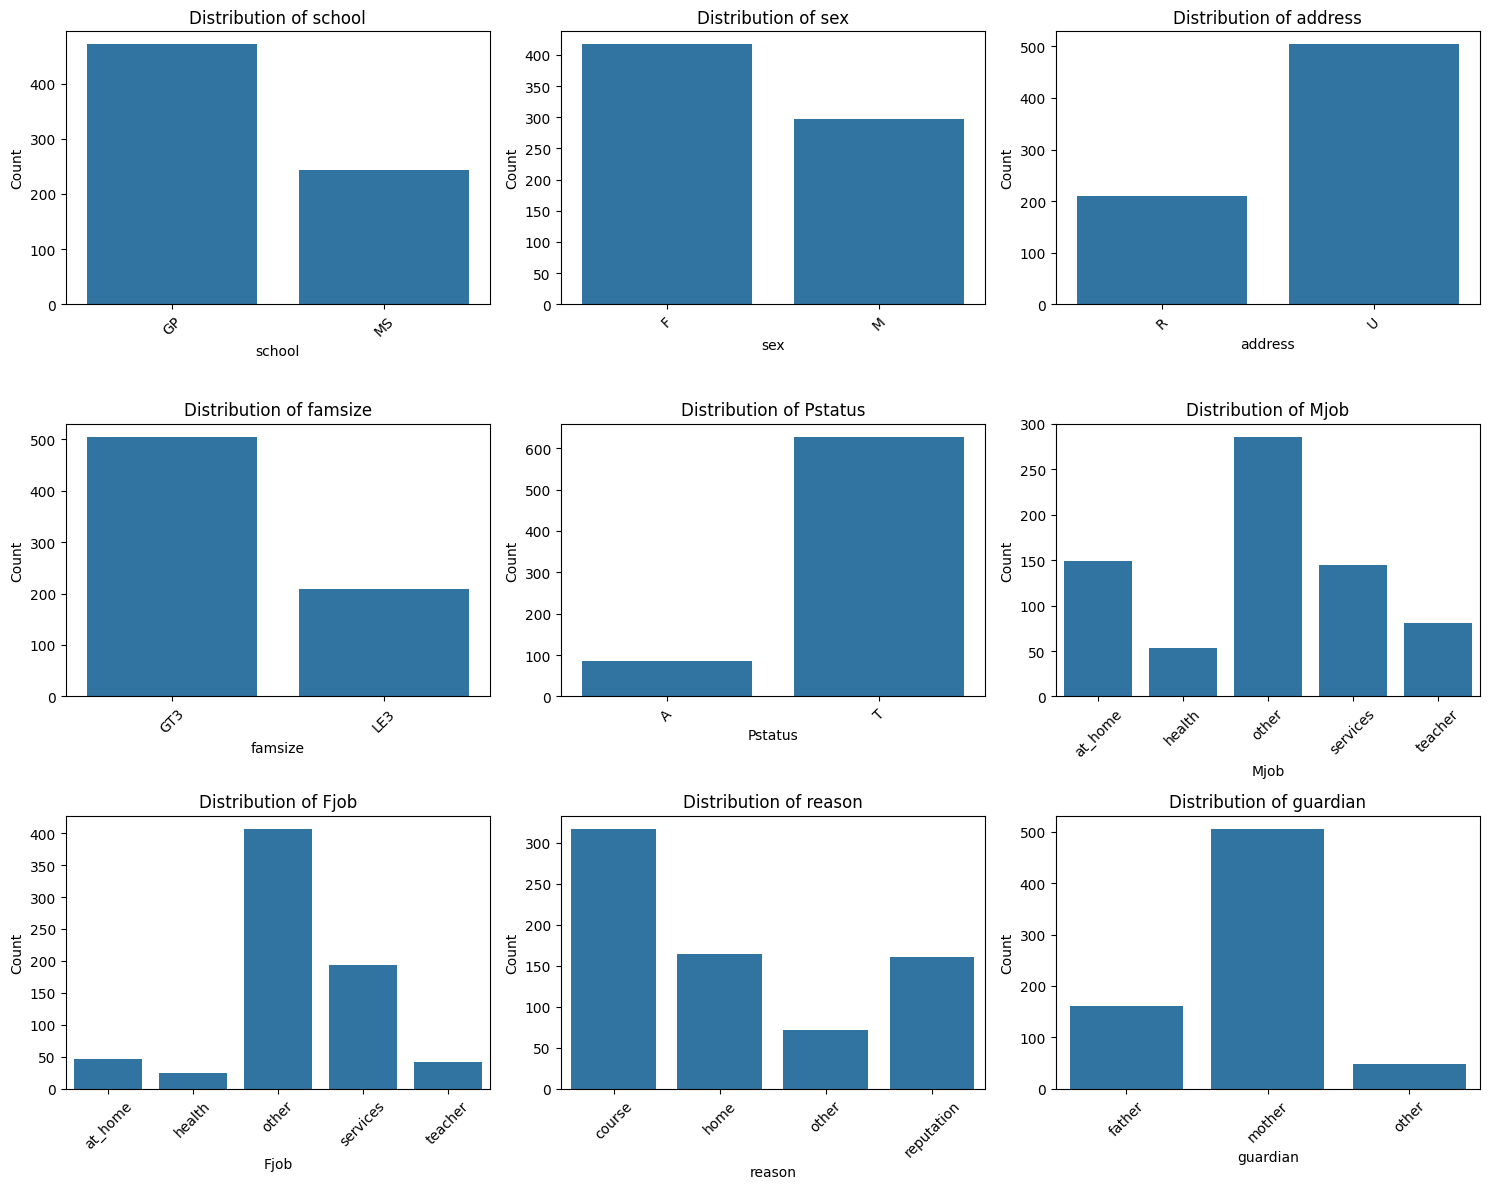

In [28]:
# Select all categorical columns
cat_cols = df.select_dtypes(include=['category']).columns

# Plot the first 9 categorical features as an example
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols[:9]):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

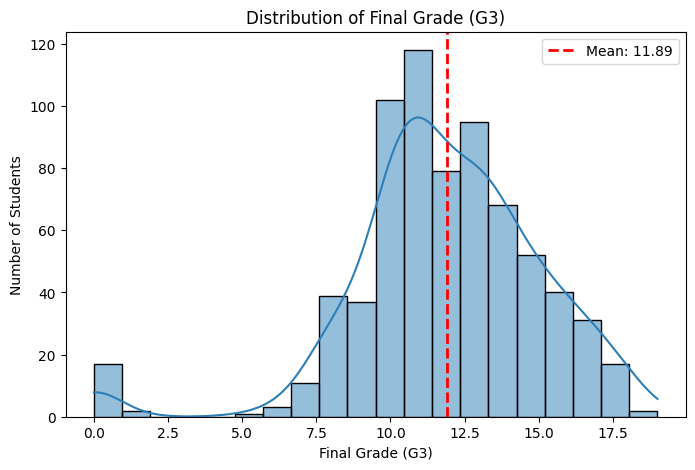

In [25]:
plt.figure(figsize=(8, 5))
sns.histplot(df['G3'], bins=20, kde=True, color='#2c7fb8')

# Add a line for the mean
mean_g3 = df['G3'].mean()
plt.axvline(mean_g3, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_g3:.2f}')

plt.title('Distribution of Final Grade (G3)')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Number of Students')
plt.legend()
plt.show()

In [26]:
# 1. Define the brush selection
brush = alt.selection_interval()

sex_color_scale = alt.Scale(domain=['F', 'M'], range=['#ff7f0e', '#1f77b4'])

base = alt.Chart(df).properties(
    width=300,
    height=250
)

# --- TOP LEFT: Context & Focus ---

# 1A. The Minimap (Used ONLY for drawing the filter box)
minimap = alt.Chart(df).mark_circle(size=15, opacity=0.6).encode(
    x=alt.X('G3:Q', axis=None), # Hide axes to save space
    y=alt.Y('absences:Q', axis=None),
    color=alt.condition(brush, alt.value('#2c7fb8'), alt.value('lightgray'))
).add_params(
    brush
).properties(
    width=300,
    height=50, # Keep it short!
    title="Navigator: Drag here to Filter & Zoom"
)

# 1B. The Main Scatter (Interactive, pans, zooms, AND is filtered by the minimap)
main_scatter = alt.Chart(df).mark_circle().transform_filter(
    brush
).encode(
    # We remove the fixed scale domains here so it can auto-zoom to your selection!
    x=alt.X('G3:Q', title='Final Grade'), 
    y=alt.Y('absences:Q', title='Absences'), 
    size=alt.Size('count():Q', title='Number of Students', scale=alt.Scale(range=[20, 600])), 
    color=alt.value('#2c7fb8'), # Solid color, no gray-out needed since it's filtered
    tooltip=['G3', 'absences', 'count()']
).properties(
    width=300,
    height=180 # Slightly shorter to accommodate the minimap above it
).interactive() # Normal scrolling and panning works perfectly here!

# Combine them vertically into a single unit
scatter_combo = minimap & main_scatter

study_labels= "datum.value == 1 ? '<2 hours' : datum.value == 2 ? '2-5 hours' : datum.value == 3 ? '5-10 hours' : '>10 hours'"

# --- TOP RIGHT: Study Time vs Final Grade ---
scatter2 = base.mark_boxplot(extent='min-max').transform_filter(
    brush
).encode(
    x=alt.X('studytime:O', title='Study Time', scale=alt.Scale(domain=[1, 2, 3, 4]), axis=alt.Axis(labelExpr=study_labels, labelAngle=-45)),
    y=alt.Y('G3:Q', title='Final Grade', scale=alt.Scale(domain=[0, 20])),
    color=alt.Color('sex:N', title='Sex', scale=sex_color_scale), # Applied flipped colors
    xOffset=alt.XOffset('sex:N', sort=['F', 'M']) # Ensure offset order remains constant
).properties(
    title="Grade Distribution by Study Time"
)

# --- BOTTOM LEFT: Heatmap for Parental Education ---
edu_labels = "datum.value == 0 ? 'None' : datum.value == 1 ? 'Primary' : datum.value == 2 ? '5th-9th' : datum.value == 3 ? 'Secondary' : 'Higher'"

heatmap_base = base.transform_filter(
    brush
).transform_aggregate(
    count='count()',
    groupby=['Medu', 'Fedu']
).encode(
    # Locked domain 0-4
    x=alt.X('Medu:O', title='Mother Education', scale=alt.Scale(domain=[0, 1, 2, 3, 4]), axis=alt.Axis(labelExpr=edu_labels, labelAngle=-45)),
    # Locked domain 4-0
    y=alt.Y('Fedu:O', title='Father Education', scale=alt.Scale(domain=[4, 3, 2, 1, 0]), axis=alt.Axis(labelExpr=edu_labels))
)

heatmap_rect = heatmap_base.mark_rect().encode(
    color=alt.Color('count:Q', scale=alt.Scale(scheme='viridis'), title='Count')
)

heatmap_text = heatmap_base.mark_text().encode(
    text='count:Q',
    color=alt.condition(
        alt.datum.count > 50,  
        alt.value('black'),
        alt.value('white')
    )
)

heatmap = (heatmap_rect + heatmap_text).properties(
    title="Parental Education Heatmap"
)


# --- BOTTOM RIGHT: Social Life Averages ---
social_plot = alt.Chart(df).transform_filter(
    brush
).transform_fold(
    ['Dalc', 'Walc', 'freetime', 'goout'],
    as_=['Metric', 'Score']
).mark_bar().encode(
    # Locked the Metric domain so columns don't vanish if unselected
    x=alt.X('Metric:N', title='Social Metric', scale=alt.Scale(domain=['Dalc', 'Walc', 'freetime', 'goout']), axis=alt.Axis(labelAngle=0)),
    y=alt.Y('mean(Score):Q', title='Average Score (1=Low, 5=High)', scale=alt.Scale(domain=[0, 5])),
    color=alt.Color('sex:N', title='Sex', scale=sex_color_scale, legend=None), # Applied flipped colors
    xOffset=alt.XOffset('sex:N', scale=alt.Scale(domain=['F', 'M'])),
    tooltip=['Metric:N', 'sex:N', 'mean(Score):Q']
).properties(
    width=300,
    height=250,
    title='Social Life Averages'
)

# Use a 2-column grid layout
dashboard = alt.concat(
    scatter_combo, scatter2, heatmap, social_plot, 
    columns=2
)

dashboard

alt.ConcatChart(...)

In [27]:
dashboard.save('student_performance_dashboard.html')